# Evaluation — Qwen2.5-VL 7B (Ollama — Vision Batch)

## Experiment metadata

| | Vision Batch (M09) |
|---|---|
| **Prompt strategy** | pdfplumber blocks + page PNG per page → Qwen2.5-VL |
| **Input files** | `data/output/labeled/qwen2.5vl-7b_vision/sampleN.json` |
| **Regenerate** | `dmpbridge-experiment experiments/qwen2-vl-vision.yaml` |
| **Provider** | Ollama (local — free) |
| **Model size** | 7B parameters, Q4_K_M |
| **Page images** | `data/output/page_images/sampleN/page_NNN.png` (shared with M08) |
| **Image sent to model** | Resized ≤ 900 px to fit 7B context window |

**Labels (5):** `title` · `section.title` · `section.description` · `question.text` · `answer.text`  
**Evaluation:** block-level accuracy + F1 against `data/input/ground_truth/sampleN_dmp.json`

---

## Sections
1. Accuracy summary
2. Per-sample accuracy
3. Confusion matrix
4. Precision / Recall / F1 per label
5. Mislabeled blocks
6. Comparison — Qwen2.5-VL 7B vs Claude Opus 4.8 (same vision-batch strategy)

In [1]:
MODEL_NAME    = "qwen2.5vl-7b"
MODEL_DISPLAY = "qwen2.5vl:7b"
COLOR_VISION  = "#0e7490"   # teal
COLOR_CLAUDE  = "#0369a1"   # blue (Claude vision for comparison)
CMAP_VISION   = "GnBu"
CMAP_CLAUDE   = "Blues"


In [2]:
from dmpbridge.evaluation.evaluate import (
    extract_gold, evaluate_sample, match,
    LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH,
    load_method, compute_f1_rows, gold_metrics,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True,
    "figure.dpi":120,
})

# Qwen vision batch
df_v, conf_v, errs_v = load_method(f"{MODEL_NAME}_vision")

# Claude vision batch for Section 6 comparison
df_c, conf_c, errs_c = load_method("claude-opus-4-8_vision")
CLAUDE_AVAILABLE = df_c is not None and not df_c.empty

tc_v, tn_v = int(df_v["correct"].sum()), int(df_v["total"].sum())
print(f"Qwen2.5-VL 7B vision batch : {tc_v}/{tn_v} ({tc_v/tn_v*100:.1f}%)")
if CLAUDE_AVAILABLE:
    tc_c, tn_c = int(df_c["correct"].sum()), int(df_c["total"].sum())
    print(f"Claude Opus 4.8 vision batch: {tc_c}/{tn_c} ({tc_c/tn_c*100:.1f}%)")


Qwen2.5-VL 7B vision batch : 639/741 (86.2%)
Claude Opus 4.8 vision batch: 702/741 (94.7%)


## 1 — Accuracy summary

- **Accuracy** = blocks where the predicted label exactly matches gold.
- Qwen2.5-VL 7B uses the same vision-batch strategy and page images as Claude M08 but runs locally at no API cost.
- A single bad sample can pull the overall number down — check the per-sample view next.

In [3]:
def print_table(df, label):
    hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
    print(f"  {label}")
    print("  " + "-" * len(hdr))
    for row in df.itertuples():
        print(f"  {row.sample:<12}  {row.total:>5}  {row.correct:>7}  "
              f"{row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
    print("  " + "-" * len(hdr))
    tn, tc = df["total"].sum(), df["correct"].sum()
    print(f"  {'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}\n")

print_table(df_v, f"Vision Batch — {MODEL_DISPLAY}")


  Vision Batch — qwen2.5vl:7b
  -------------------------------------------------------
  sample1          78       75       3     96.2%  75/78
  sample2         172      126      46     73.3%  126/172
  sample3          69       46      23     66.7%  46/69
  sample4          78       77       1     98.7%  77/78
  sample5          86       72      14     83.7%  72/86
  sample6          29       21       8     72.4%  21/29
  sample7          17       17       0    100.0%  17/17
  sample8          59       56       3     94.9%  56/59
  sample9          85       81       4     95.3%  81/85
  sample10         68       68       0    100.0%  68/68
  -------------------------------------------------------
  TOTAL           741      639     102     86.2%  639/741



## 2 — Per-sample accuracy

Colour coding: green ≥ 90%, amber 80–90%, red < 80%.  
Samples below 80% are candidates for prompt tuning or fine-tuning.

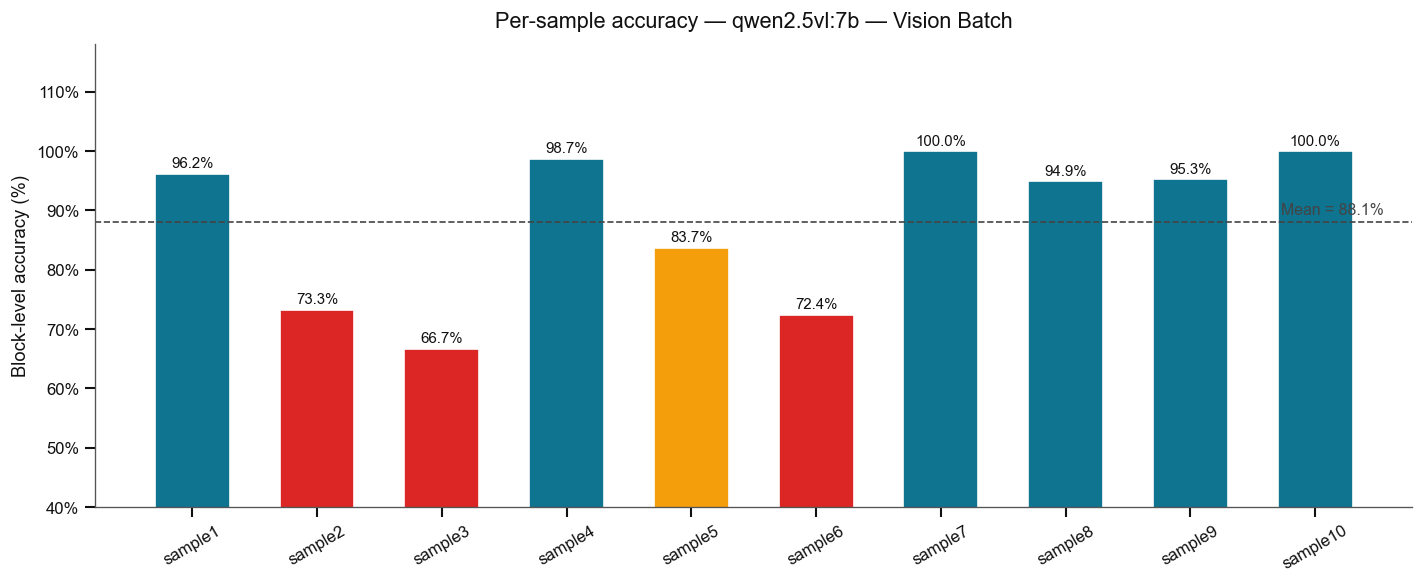

In [4]:
samples_ordered = df_v["sample"].tolist()
x = range(len(samples_ordered))
acc_v = df_v.set_index("sample").loc[samples_ordered, "accuracy"] * 100
colors = [COLOR_VISION if v >= 90 else "#f59e0b" if v >= 80 else "#dc2626"
          for v in acc_v]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(samples_ordered, acc_v, color=colors, width=0.6, edgecolor="white")
for bar, v in zip(bars, acc_v):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
avg_v = acc_v.mean()
ax.axhline(avg_v, color="#444", linestyle="--", linewidth=1.0)
ax.text(len(x)-0.45, avg_v + 0.7, f"Mean = {avg_v:.1f}%",
        ha="right", va="bottom", fontsize=9.5, color="#444")
ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
ax.set_ylim(40, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_DISPLAY} — Vision Batch", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine(); plt.tight_layout(); plt.show()


## 3 — Confusion matrix

Read **row by row**: each row = a true label, each column = what the model predicted.  
A perfect model has all mass on the diagonal.  
The key pair to watch: `question.text` vs `section.description` — both are funder-written text; the boundary is structural, not lexical.

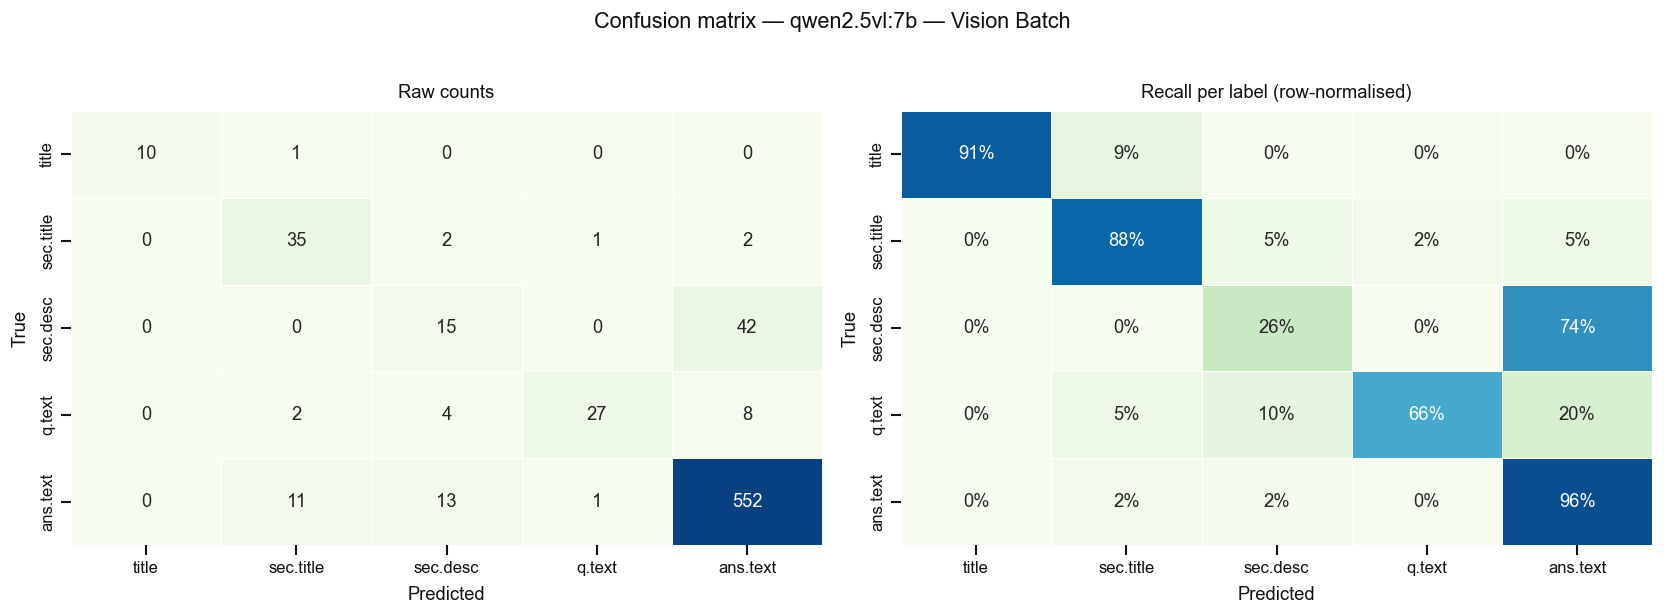

In [5]:
def conf_to_df(conf):
    m = pd.DataFrame(
        [[conf.get(t, {}).get(p, 0) for p in LABELS] for t in LABELS],
        index=SHORT, columns=SHORT)
    return m, m.div(m.sum(axis=1).replace(0, 1), axis=0)

mat_v, mat_vn = conf_to_df(conf_v)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, fmt, title in [
    (axes[0], mat_v,  "d",   "Raw counts"),
    (axes[1], mat_vn, ".0%", "Recall per label (row-normalised)"),
]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=CMAP_VISION, linewidths=0.6,
                linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
    ax.set_title(title, pad=8, fontsize=11)
    ax.set_xlabel("Predicted", labelpad=6)
    ax.set_ylabel("True", labelpad=6)
plt.suptitle(f"Confusion matrix — {MODEL_DISPLAY} — Vision Batch", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 4 — Precision / Recall / F1 per label

F1 balances precision and recall. Values below 80% indicate a label the model struggles to classify reliably.
`question.text` and `section.description` are historically the hardest pair.

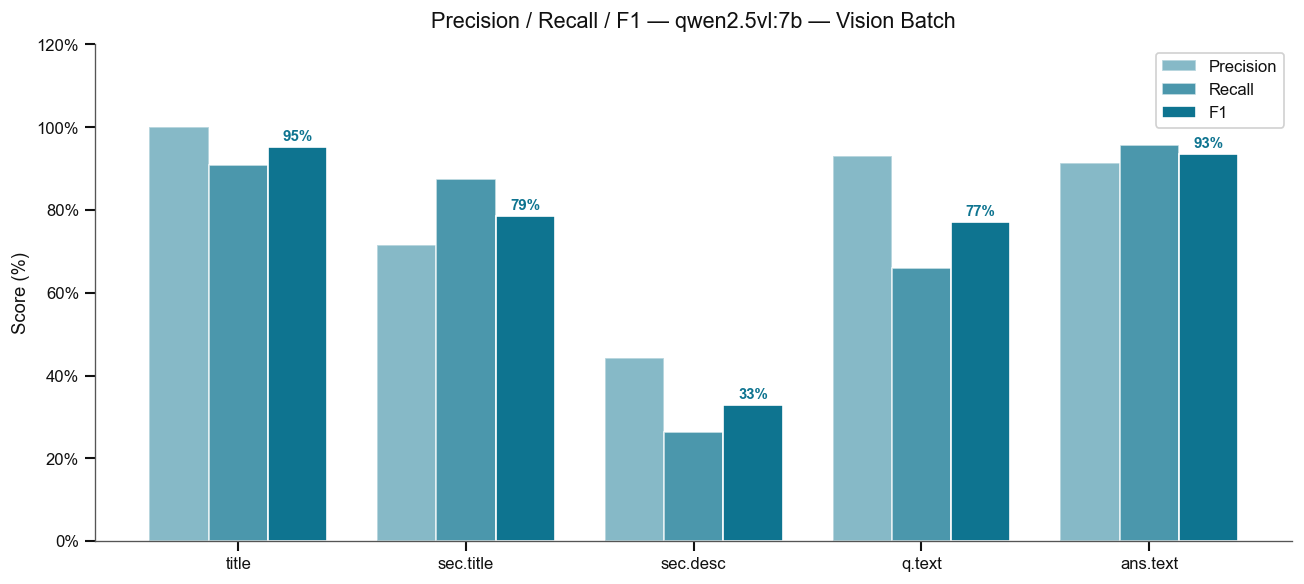

,precision,recall,f1,support
label,,,,
title,100.0%,90.9%,95.2%,1100.0%
section.title,71.4%,87.5%,78.7%,4000.0%
section.description,44.1%,26.3%,33.0%,5700.0%
question.text,93.1%,65.9%,77.1%,4100.0%
answer.text,91.4%,95.7%,93.5%,57700.0%


In [6]:
df_f1_v = compute_f1_rows(conf_v)
xi, bw = range(len(LABELS)), 0.26

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - bw for i in xi], df_f1_v["precision"]*100, width=bw, label="Precision",
       color=COLOR_VISION, alpha=0.5, edgecolor="white")
ax.bar([i      for i in xi], df_f1_v["recall"]*100,    width=bw, label="Recall",
       color=COLOR_VISION, alpha=0.75, edgecolor="white")
bars = ax.bar([i + bw for i in xi], df_f1_v["f1"]*100, width=bw, label="F1",
              color=COLOR_VISION, edgecolor="white")
for bar, row in zip(bars, df_f1_v.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{row.f1*100:.0f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=COLOR_VISION)
ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 120); ax.set_ylabel("Score (%)")
ax.set_title(f"Precision / Recall / F1 — {MODEL_DISPLAY} — Vision Batch", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(loc="upper right", framealpha=0.9)
sns.despine(); plt.tight_layout(); plt.show()

display(df_f1_v.set_index("label").style.format("{:.1%}")
        .background_gradient(subset=["f1"], cmap="GnBu"))


## 5 — Mislabeled blocks

Systematic errors (same true→pred pair, many blocks) signal a prompt or label issue.  
Isolated errors are acceptable noise.

In [7]:
def error_breakdown(df_err, label):
    print(f"  {label}: {len(df_err)} mislabeled blocks")
    if df_err.empty:
        print("  No errors.\n"); return
    bd = (df_err.groupby(["true","pred"]).size()
          .reset_index(name="count").sort_values("count", ascending=False))
    print(bd.to_string(index=False)); print()

error_breakdown(errs_v, f"Vision Batch — {MODEL_DISPLAY}")


  Vision Batch — qwen2.5vl:7b: 90 mislabeled blocks
               true                pred  count
section.description         answer.text     42
        answer.text section.description     13
        answer.text       section.title     11
      question.text         answer.text      8
      question.text section.description      4
           no_match         answer.text      3
      section.title         answer.text      2
      question.text       section.title      2
      section.title section.description      2
        answer.text       question.text      1
      section.title       question.text      1
              title       section.title      1



In [8]:
pd.set_option("display.max_colwidth", 100)
if not errs_v.empty:
    display(errs_v[["sample","page","true","pred","text"]].reset_index(drop=True))


,sample,page,true,pred,text
0,sample1,1,answer.text,question.text,study.
1,sample1,2,answer.text,section.description,"repository (the RISE study, the iWATCH study, and NHANES) and for data storage on the University of"
2,sample1,2,question.text,answer.text,"Protections for privacy, rights, and confidentiality of human research participants:"
3,sample2,1,answer.text,section.description,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help from the"
4,sample2,1,answer.text,section.title,and will be responsible for checking that the plan is being followed.
...,...,...,...,...,...
85,sample8,2,answer.text,section.description,"Stored materials are downloadable but not editable, and they are backed up to assure no loss of ..."
86,sample9,1,title,section.title,ELECTRODES
87,sample9,3,answer.text,section.description,extensions (and conditions under which they can use and modify the code) will be uploaded to the
88,sample9,3,answer.text,section.title,CASM.


## 6 — Comparison: Qwen2.5-VL 7B (local) vs Claude Opus 4.8 (API)

Both models use the exact same `vision_batch` strategy and the same page PNG files.  
The only difference is the model and provider:

| | Qwen2.5-VL 7B (M09) | Claude Opus 4.8 (M08) |
|---|---|---|
| Provider | Ollama (local) | Anthropic API |
| Cost | Free | Paid per token |
| Image resolution sent | ≤ 900 px (resized) | 150 DPI original |
| Context window | 8 192 tokens | Unlimited (API) |

This comparison isolates the effect of model capability on the vision-batch strategy.

=== Overall accuracy ===

  Qwen2.5-VL 7B  (M09)      639/741  (86.2%)
  Claude Opus 4.8 (M08)     702/741  (94.7%)


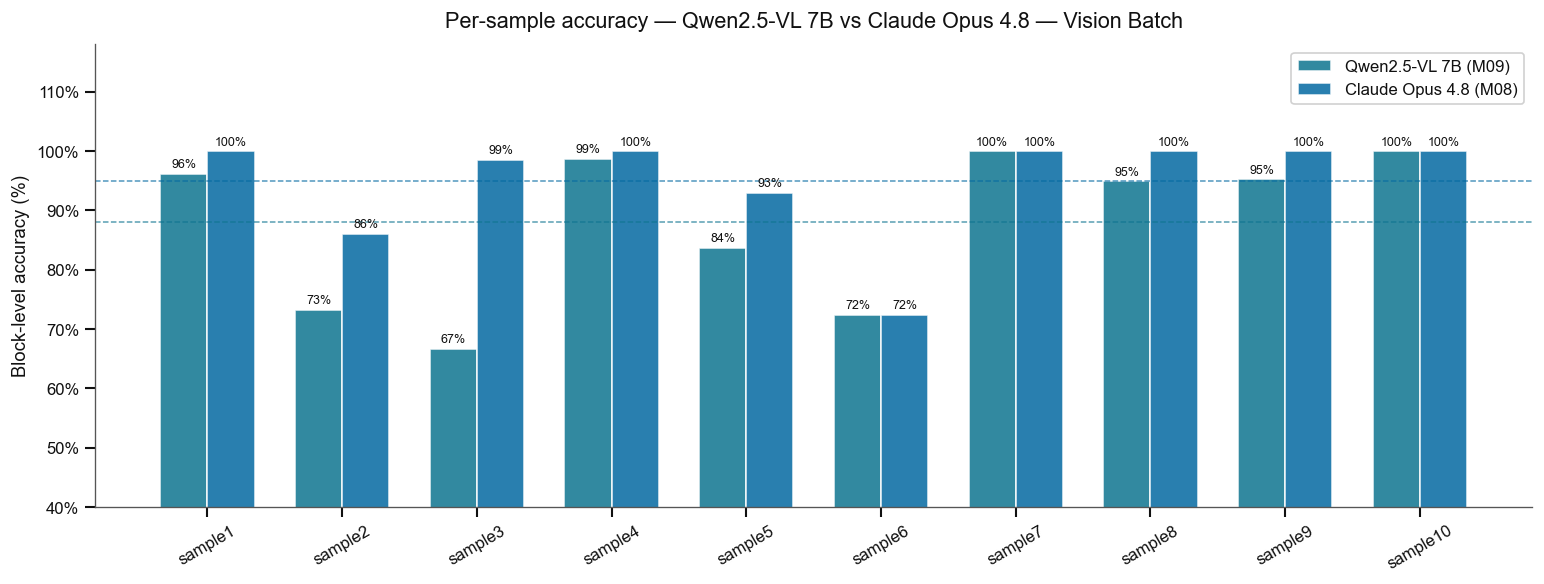


=== Per-sample delta (Qwen − Claude) ===

  Sample            Qwen    Claude     Delta
  --------------------------------------------
  sample1          96.2%    100.0%    -3.8%
  sample2          73.3%     86.0%   -12.8%
  sample3          66.7%     98.6%   -31.9%
  sample4          98.7%    100.0%    -1.3%
  sample5          83.7%     93.0%    -9.3%
  sample6          72.4%     72.4%  +   0.0%
  sample7         100.0%    100.0%  +   0.0%
  sample8          94.9%    100.0%    -5.1%
  sample9          95.3%    100.0%    -4.7%
  sample10        100.0%    100.0%  +   0.0%
  --------------------------------------------
  OVERALL          86.2%     94.7%    -8.5%


In [9]:
if CLAUDE_AVAILABLE:
    # ── Overall accuracy ─────────────────────────────────────────────────
    print("=== Overall accuracy ===\n")
    for label, df in [(f"Qwen2.5-VL 7B  (M09)", df_v), ("Claude Opus 4.8 (M08)", df_c)]:
        tc_ = int(df["correct"].sum()); tn_ = int(df["total"].sum())
        print(f"  {label:<24}  {tc_}/{tn_}  ({tc_/tn_*100:.1f}%)")

    # ── Per-sample accuracy side-by-side ──────────────────────────────────
    merged = df_v[["sample","accuracy"]].rename(columns={"accuracy":"qwen"})\
             .merge(df_c[["sample","accuracy"]].rename(columns={"accuracy":"claude"}), on="sample")
    merged["delta"] = merged["qwen"] - merged["claude"]

    samples_ordered = merged["sample"].tolist()
    x = range(len(samples_ordered))
    w = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    bars_q = ax.bar([xi - w/2 for xi in x], merged["qwen"]*100, width=w,
                    label=f"Qwen2.5-VL 7B (M09)", color=COLOR_VISION, alpha=0.85, edgecolor="white")
    bars_c = ax.bar([xi + w/2 for xi in x], merged["claude"]*100, width=w,
                    label="Claude Opus 4.8 (M08)", color=COLOR_CLAUDE, alpha=0.85, edgecolor="white")
    for bar, v in list(zip(bars_q, merged["qwen"]*100)) + list(zip(bars_c, merged["claude"]*100)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5)
    ax.axhline(merged["qwen"].mean()*100, color=COLOR_VISION, linestyle="--", linewidth=0.9, alpha=0.7)
    ax.axhline(merged["claude"].mean()*100, color=COLOR_CLAUDE, linestyle="--", linewidth=0.9, alpha=0.7)
    ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
    ax.set_ylim(40, 118); ax.set_ylabel("Block-level accuracy (%)")
    ax.set_title("Per-sample accuracy — Qwen2.5-VL 7B vs Claude Opus 4.8 — Vision Batch", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(framealpha=0.9); sns.despine(); plt.tight_layout(); plt.show()

    # ── Delta table ───────────────────────────────────────────────────────
    print("\n=== Per-sample delta (Qwen − Claude) ===\n")
    print(f"  {'Sample':<12}  {'Qwen':>8}  {'Claude':>8}  {'Delta':>8}")
    print("  " + "-" * 44)
    for _, r in merged.iterrows():
        sign = '+' if r['delta'] >= 0 else ''
        print(f"  {r['sample']:<12}  {r['qwen']*100:>7.1f}%  {r['claude']*100:>7.1f}%  {sign}{r['delta']*100:>6.1f}%")
    print("  " + "-" * 44)
    dq = df_v['correct'].sum()/df_v['total'].sum()
    dc = df_c['correct'].sum()/df_c['total'].sum()
    sign = '+' if (dq-dc) >= 0 else ''
    print(f"  {'OVERALL':<12}  {dq*100:>7.1f}%  {dc*100:>7.1f}%  {sign}{(dq-dc)*100:>6.1f}%")
else:
    print("Claude vision data not available — run: dmpbridge-experiment experiments/claude-opus-4-8-vision.yaml")


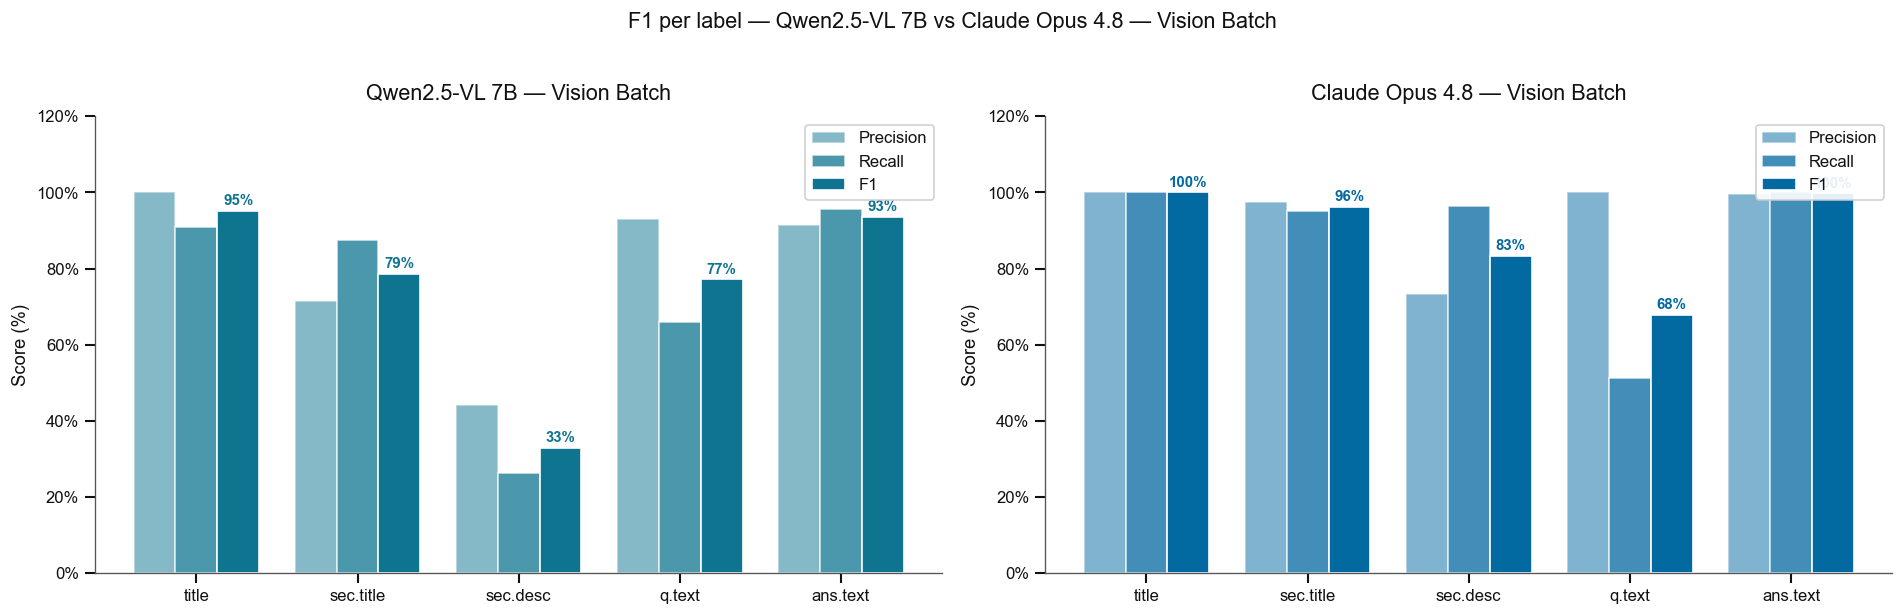

,qwen_f1,claude_f1,Δ qwen−claude
label,,,
title,95.2%,100.0%,-4.8%
section.title,78.7%,96.2%,-17.6%
section.description,33.0%,83.3%,-50.4%
question.text,77.1%,67.7%,9.4%
answer.text,93.5%,99.7%,-6.3%


In [10]:
if CLAUDE_AVAILABLE:
    df_f1_c = compute_f1_rows(conf_c)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, df_f1, color, title in [
        (axes[0], df_f1_v, COLOR_VISION, f"Qwen2.5-VL 7B — Vision Batch"),
        (axes[1], df_f1_c, COLOR_CLAUDE, f"Claude Opus 4.8 — Vision Batch"),
    ]:
        xi, bw = range(len(LABELS)), 0.26
        ax.bar([i - bw for i in xi], df_f1["precision"]*100, width=bw, label="Precision",
               color=color, alpha=0.5, edgecolor="white")
        ax.bar([i      for i in xi], df_f1["recall"]*100,    width=bw, label="Recall",
               color=color, alpha=0.75, edgecolor="white")
        bars = ax.bar([i + bw for i in xi], df_f1["f1"]*100, width=bw, label="F1",
                      color=color, edgecolor="white")
        for bar, row in zip(bars, df_f1.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                    f"{row.f1*100:.0f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color=color)
        ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
        ax.set_ylim(0, 120); ax.set_ylabel("Score (%)")
        ax.set_title(title, pad=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
        ax.legend(loc="upper right", framealpha=0.9); sns.despine(ax=ax)
    plt.suptitle("F1 per label — Qwen2.5-VL 7B vs Claude Opus 4.8 — Vision Batch",
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    # ── F1 delta table ────────────────────────────────────────────────────
    cmp = df_f1_v.set_index("label")[["f1"]].rename(columns={"f1":"qwen_f1"})\
          .join(df_f1_c.set_index("label")[["f1"]].rename(columns={"f1":"claude_f1"}))
    cmp["Δ qwen−claude"] = cmp["qwen_f1"] - cmp["claude_f1"]
    display(cmp.style.format("{:.1%}")
            .background_gradient(subset=["qwen_f1","claude_f1"], cmap="Blues"))


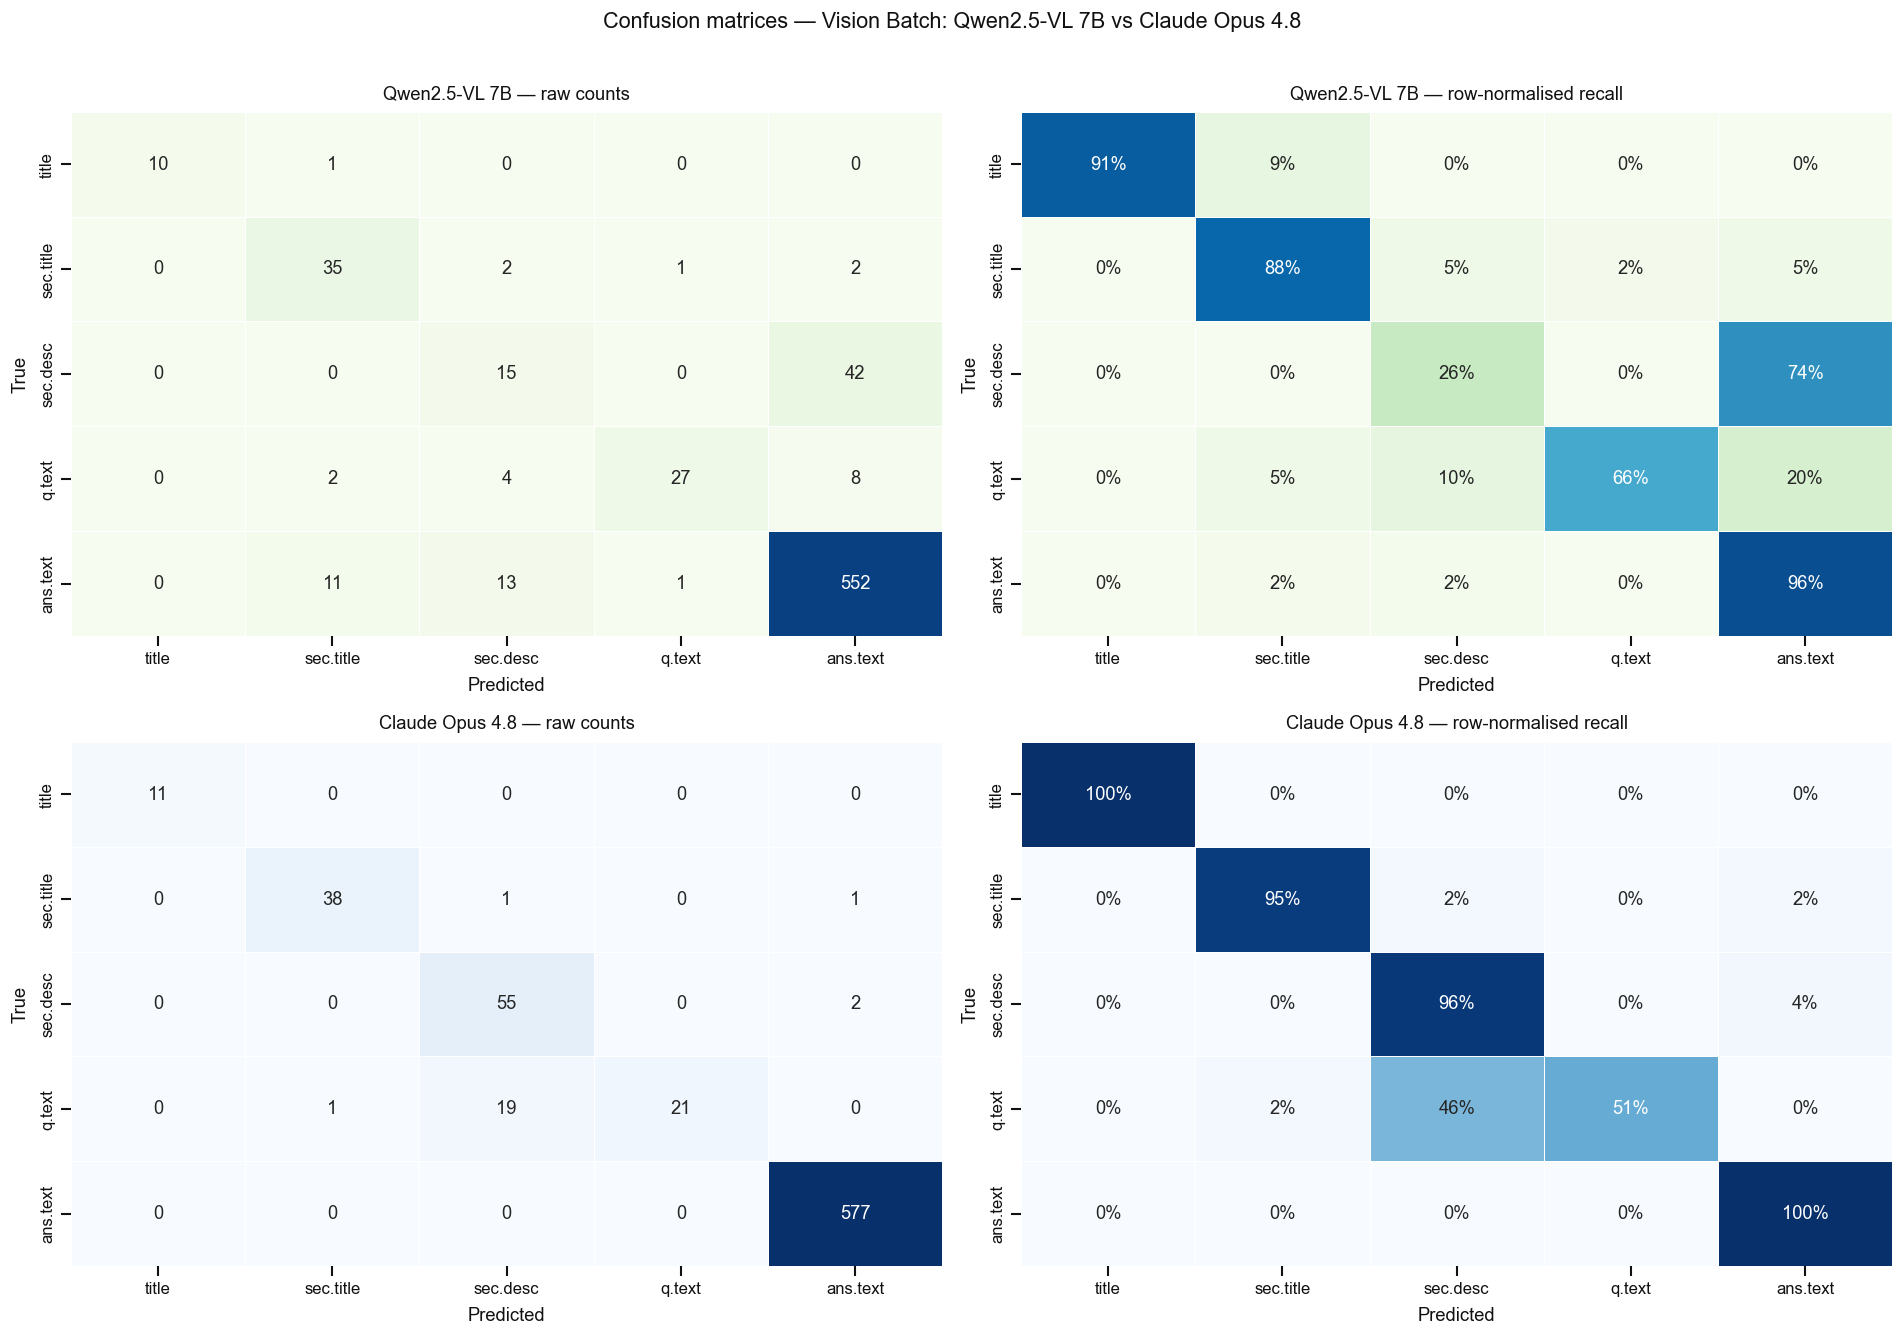

In [11]:
if CLAUDE_AVAILABLE:
    mat_c, mat_cn = conf_to_df(conf_c)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    panels = [
        (axes[0,0], mat_v,  "d",   CMAP_VISION, "Qwen2.5-VL 7B — raw counts"),
        (axes[0,1], mat_vn, ".0%", CMAP_VISION, "Qwen2.5-VL 7B — row-normalised recall"),
        (axes[1,0], mat_c,  "d",   CMAP_CLAUDE, "Claude Opus 4.8 — raw counts"),
        (axes[1,1], mat_cn, ".0%", CMAP_CLAUDE, "Claude Opus 4.8 — row-normalised recall"),
    ]
    for ax, mat, fmt, cmap, title in panels:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, linewidths=0.6,
                    linecolor="white", ax=ax, cbar=False, annot_kws={"size":11},
                    vmin=(0 if fmt==".0%" else None), vmax=(1 if fmt==".0%" else None))
        ax.set_title(title, pad=8, fontsize=11)
        ax.set_xlabel("Predicted", labelpad=6); ax.set_ylabel("True", labelpad=6)
    plt.suptitle("Confusion matrices — Vision Batch: Qwen2.5-VL 7B vs Claude Opus 4.8",
                 fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()
